In [1]:
import pandas as pd

file_path = r"C:\Users\ayush\Downloads\COVID-19 Data  project\0.5_sample_cleaned_dataset\0.5_sample_cleaned_dataset.xls"

df = pd.read_csv(file_path, nrows=100000, low_memory=False)

df.head()

,cdc_case_earliest_dt,cdc_report_dt,pos_spec_dt,current_status,sex,age_group,race_ethnicity_combined,hosp_yn,icu_yn,death_yn,medcond_yn,year,month,day_of_week
0,2021-08-11,2021-08-13,NaN,Laboratory-confirmed case,Male,10 - 19 Years,Hispanic/Latino,0,-1,-1,-1,2021,8,Wednesday
1,2021-01-14,2021-02-02,NaN,Laboratory-confirmed case,Male,10 - 19 Years,Hispanic/Latino,0,-1,0,-1,2021,1,Thursday
2,2022-01-25,NaN,NaN,Laboratory-confirmed case,Male,10 - 19 Years,Hispanic/Latino,-1,-1,-1,-1,2022,1,Tuesday
3,2022-01-30,2022-09-28,NaN,Laboratory-confirmed case,Male,10 - 19 Years,Hispanic/Latino,-1,-1,-1,-1,2022,1,Sunday
4,2022-08-23,2022-08-23,NaN,Laboratory-confirmed case,Male,10 - 19 Years,Hispanic/Latino,-1,-1,-1,-1,2022,8,Tuesday


In [2]:
# Only drop rows where date is missing (important for time series)
df = df.dropna(subset=['cdc_report_dt'])

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 92085 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   cdc_case_earliest_dt     92085 non-null  object
 1   cdc_report_dt            92085 non-null  object
 2   pos_spec_dt              42269 non-null  object
 3   current_status           92085 non-null  object
 4   sex                      92085 non-null  object
 5   age_group                92085 non-null  object
 6   race_ethnicity_combined  92085 non-null  object
 7   hosp_yn                  92085 non-null  int64 
 8   icu_yn                   92085 non-null  int64 
 9   death_yn                 92085 non-null  int64 
 10  medcond_yn               92085 non-null  int64 
 11  year                     92085 non-null  int64 
 12  month                    92085 non-null  int64 
 13  day_of_week              92085 non-null  object
dtypes: int64(6), object(8)
memory usage: 10.5+ 

,hosp_yn,icu_yn,death_yn,medcond_yn,year,month
count,92085.000000,92085.000000,92085.000000,92085.000000,92085.000000,92085.000000
mean,-0.625813,-0.967639,-0.641168,-0.874800,2021.386339,6.436879
std,0.540843,0.187507,0.492947,0.418938,0.960401,4.078780
min,-1.000000,-1.000000,-1.000000,-1.000000,2020.000000,1.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,2021.000000,2.000000
50%,-1.000000,-1.000000,-1.000000,-1.000000,2021.000000,7.000000
75%,0.000000,-1.000000,0.000000,-1.000000,2022.000000,10.000000
max,1.000000,1.000000,1.000000,1.000000,2024.000000,12.000000


In [4]:
df.isnull().sum()

cdc_case_earliest_dt           0
cdc_report_dt                  0
pos_spec_dt                49816
current_status                 0
sex                            0
age_group                      0
race_ethnicity_combined        0
hosp_yn                        0
icu_yn                         0
death_yn                       0
medcond_yn                     0
year                           0
month                          0
day_of_week                    0
dtype: int64

In [5]:
df['age_group'].value_counts()

age_group
30 - 39 Years    25389
60 - 69 Years    23918
40 - 49 Years    13056
10 - 19 Years    12217
50 - 59 Years     9443
70 - 79 Years     4284
0 - 9 Years       1935
Unknown           1012
20 - 29 Years      641
80+ Years          190
Name: count, dtype: int64

In [6]:
df['sex'].value_counts()

sex
Female     55376
Male       36157
Unknown      548
Other          4
Name: count, dtype: int64

In [7]:
df['hosp_yn'].value_counts()

hosp_yn
-1    60314
 0    29085
 1     2686
Name: count, dtype: int64

In [9]:
df['death_yn'].value_counts()

death_yn
-1    59637
 0    31853
 1      595
Name: count, dtype: int64

<Axes: title={'center': 'Death Distribution'}, xlabel='death_yn'>

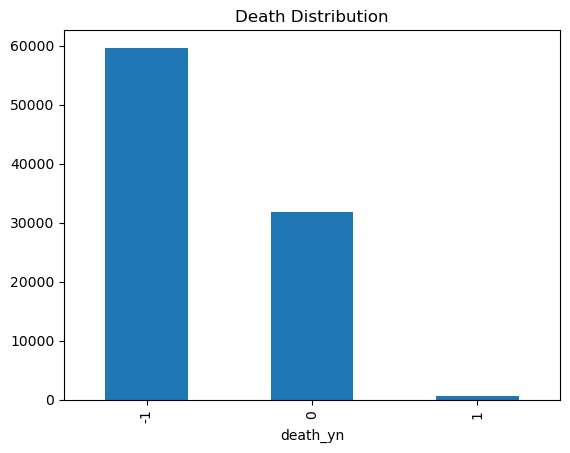

In [10]:
df['death_yn'].value_counts().plot(kind='bar', title='Death Distribution')

In [11]:
df['cdc_report_dt'] = pd.to_datetime(df['cdc_report_dt'], errors='coerce')

daily_cases = df.groupby('cdc_report_dt').size().reset_index(name='cases')

daily_cases.head()

,cdc_report_dt,cases
0,2020-02-28,1
1,2020-03-11,1
2,2020-03-13,1
3,2020-03-16,2
4,2020-03-17,3


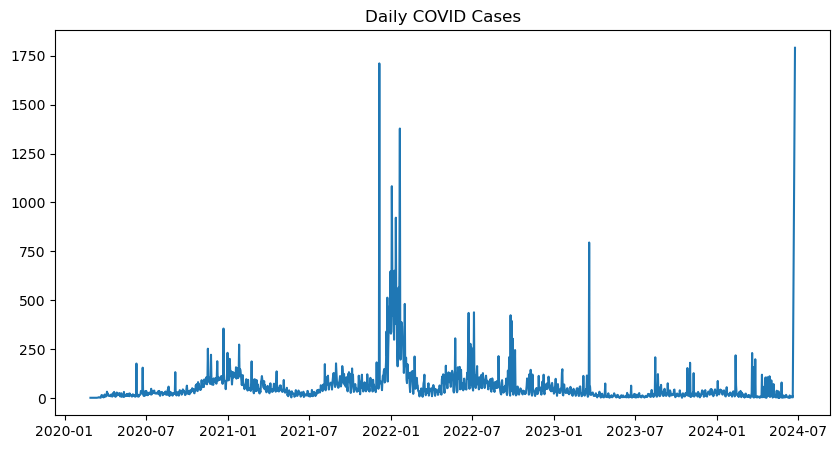

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily_cases['cdc_report_dt'], daily_cases['cases'])
plt.title("Daily COVID Cases")
plt.show()

 ## Data Acquisition and Exploratory Analysis

## 1. Obtain the Dataset and Data Cleaning

The CDC COVID-19 Case Surveillance Public Use dataset was obtained and used for this project. A cleaned sample dataset was utilized to ensure consistency across team members and improve data quality.

The dataset was loaded into Python using the Pandas library. Since the original dataset is very large, a representative, cleaned sample dataset was used to enable efficient processing and analysis.

During the data cleaning process, missing values were handled appropriately. Instead of removing all incomplete records, only rows with missing reporting dates (`cdc_report_dt`) were excluded. This ensured that time-series analysis could be performed accurately while preserving the majority of the dataset.

Additionally, categorical variables such as hospitalization, ICU admission, and death status were encoded numerically, where:

* `1` represents “Yes.”
* `0` represents “No.”
* `-1` represents “Missing”

---

## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to understand the structure and characteristics of the dataset.

The dataset contains 14 variables, including:

* Temporal variables (`cdc_report_dt`, year, month)
* Demographic variables (`age_group`, `sex`, `race_ethnicity_combined`)
* Clinical variables (`hosp_yn`, `icu_yn`, `death_yn`, `medcond_yn`)

Most variables are categorical, while date variables were converted into a datetime format to support time-based analysis.

Summary statistics and data inspection confirmed that the dataset is clean and suitable for further analysis.

---

## 3. Examine Distributions

Distribution analysis was performed on key variables to understand data patterns.

* **Age Group:**
  Most cases fall within the 30–39 and 60–69 age groups, indicating higher reporting in adult populations.

* **Sex:**
  The dataset shows more female cases than male cases, with very few entries in the “Unknown” or “Other” categories.

* **Hospitalization (`hosp_yn`):**
  The majority of cases are either “No” or “Missing,” with relatively few hospitalized cases.

* **Death (`death_yn`):**
  Most cases indicate “No” or “Missing,” while very few cases result in death. This indicates a strong class imbalance in mortality outcomes.

These distributions highlight key characteristics of the dataset, including imbalance and real-world reporting limitations.

---

## 4. Time-Based Analysis

To analyze temporal trends, the dataset was transformed into a time-series format by aggregating case-level data into daily counts using the reporting date (`cdc_report_dt`).

The resulting time-series shows:

* Significant fluctuations in daily case counts
* Clear peaks during major COVID-19 waves (especially around 2021–2022)
* Sudden spikes and drops, indicating possible reporting delays or data corrections

These irregular patterns suggest anomalies in the dataset, making it suitable for anomaly detection.

---

## 5. Identify Variables for Anomaly Detection

Based on the exploratory analysis, the following variables were selected for anomaly detection:

* **cdc_report_dt (Time Variable):**
  Used to construct time-series data and detect temporal anomalies.

* **cases (Derived Variable):**
  Created by aggregating records into daily case counts. This is the primary signal for identifying unusual patterns.

* **hosp_yn (Hospitalization):**
  Indicates case severity and helps identify anomalies in healthcare burden.

* **death_yn (Outcome Variable):**
  Helps detect unusual mortality spikes or trends.

* **age_group (Demographic Variable):**
  Allows analysis of anomalies across different population segments.

Additional derived features, such as daily changes in case counts and rolling averages, will be used in subsequent modeling steps.

---

## Summary

 The dataset was successfully obtained, cleaned, and explored. Key distributions and temporal trends were analyzed, and relevant variables were identified for anomaly detection. 